<a href="https://colab.research.google.com/github/yangbohan-21/Marketing-Analytics-Projects-/blob/main/SocialMediaStrategyProject_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [307]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [308]:
import pandas as pd
file_path = '/content/drive/MyDrive/CaseCompetition_Group4/IG _POSTS_withContentTypes.csv'
df_posts = pd.read_csv(file_path)
display(df_posts.head())
print("\nDataFrame Shape:")
print(df_posts.shape)
print("\nDataFrame Info:")
df_posts.info()

,Post ID,Account ID,Account username,Account name,Description,Duration (sec),Publish time,Permalink,Post type,Data comment,Date,Views,Reach,Likes,Shares,Follows,Comments,Saves,content_type
0,17917032761583900,17841411888867000,presidentfolt,Carol Folt,Love the energy and Trojan spirit in the stadi...,0,01/02/2023 10:41,https://www.instagram.com/p/Cm7Fge1vAy3/,IG carousel,NaN,Lifetime,NaN,119.0,1011,1,0.0,11,14,Recognition/Motivation
1,18191401399218100,17841411888867000,presidentfolt,Carol Folt,"Tough loss, @uscfb. An incredible run this yea...",0,01/02/2023 14:40,https://www.instagram.com/p/Cm7g08kS76a/,IG image,NaN,Lifetime,NaN,61.0,835,0,0.0,19,8,Recognition/Motivation
2,17977481773795600,17841411888867000,presidentfolt,Carol Folt,"The holidays may be over, but I wanted to shar...",0,01/05/2023 14:01,https://www.instagram.com/p/CnDKxBISGYA/,IG carousel,NaN,Lifetime,NaN,79.0,239,0,0.0,2,1,Recognition/Motivation
3,17982300532875100,17841411888867000,presidentfolt,Carol Folt,"Welcome back, Trojans. Wishing you an outstand...",171,01/10/2023 10:37,https://www.instagram.com/reel/CnPrNlnLAKc/,IG reel,NaN,Lifetime,NaN,88.0,513,0,0.0,12,10,Recognition/Motivation
4,17959038683488200,17841411888867000,presidentfolt,Carol Folt,Huge win against #2 Stanford! Congrats @uscwbb!,0,01/15/2023 16:05,https://www.instagram.com/p/CndI1yOv_I_/,IG image,NaN,Lifetime,NaN,78.0,644,0,0.0,9,7,Recognition/Motivation



DataFrame Shape:
(847, 19)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Post ID           847 non-null    int64  
 1   Account ID        847 non-null    int64  
 2   Account username  847 non-null    object 
 3   Account name      846 non-null    object 
 4   Description       846 non-null    object 
 5   Duration (sec)    847 non-null    int64  
 6   Publish time      847 non-null    object 
 7   Permalink         847 non-null    object 
 8   Post type         847 non-null    object 
 9   Data comment      0 non-null      float64
 10  Date              847 non-null    object 
 11  Views             134 non-null    float64
 12  Reach             804 non-null    float64
 13  Likes             847 non-null    int64  
 14  Shares            847 non-null    int64  
 15  Follows           794 non-null    float64
 16 

## DataCleaning



In [309]:
print("Original DataFrame Info:")
df_posts.info()

# Create a copy to avoid SettingWithCopyWarning
df_posts_cleaned = df_posts.copy()

# 1. Identify and remove columns that are entirely empty, e.g., 'Data comment'
# Check which columns have all NaN values
empty_cols = df_posts_cleaned.columns[df_posts_cleaned.isnull().all()].tolist()
print(f"\nColumns with all NaN values to be dropped: {empty_cols}") # 打印将要删除的全部为NaN的列 / Print columns with all NaN values to be dropped
df_posts_cleaned = df_posts_cleaned.dropna(axis=1, how='all')
print("DataFrame after dropping empty columns:")
df_posts_cleaned.info()

# 2. Handle missing values in 'Account name' and 'Description' columns
# Replace NaN values with 'Unknown'
df_posts_cleaned.loc[:, 'Account name'] = df_posts_cleaned['Account name'].fillna('Unknown')
df_posts_cleaned.loc[:, 'Description'] = df_posts_cleaned['Description'].fillna('Unknown')
print("\nMissing values in 'Account name' after filling:", df_posts_cleaned['Account name'].isnull().sum()) # 打印填充后'Account name'中的缺失值 / Print missing values in 'Account name' after filling
print("Missing values in 'Description' after filling:", df_posts_cleaned['Description'].isnull().sum()) # 打印填充后'Description'中的缺失值 / Print missing values in 'Description' after filling

# 3.Handle missing values in numerical columns 'Views', 'Reach', 'Follows'
#  Replace NaN values in these columns with 0
df_posts_cleaned.loc[:, 'Views'] = df_posts_cleaned['Views'].fillna(0)
df_posts_cleaned.loc[:, 'Reach'] = df_posts_cleaned['Reach'].fillna(0)
df_posts_cleaned.loc[:, 'Follows'] = df_posts_cleaned['Follows'].fillna(0)
print("\nMissing values in 'Views' after filling:", df_posts_cleaned['Views'].isnull().sum())
print("Missing values in 'Reach' after filling:", df_posts_cleaned['Reach'].isnull().sum())
print("Missing values in 'Follows' after filling:", df_posts_cleaned['Follows'].isnull().sum())

# 4. Convert 'Publish time' column from 'object' to datetime format
df_posts_cleaned.loc[:, 'Publish time'] = pd.to_datetime(df_posts_cleaned['Publish time'])
print("\nDataFrame Info after type conversion and filling NaN:")
df_posts_cleaned.info()

# 5. Check for duplicate rows in the DataFrame
columns_to_check = ['Post ID', 'Publish time']
duplicate_rows = df_posts_cleaned.duplicated(subset=columns_to_check).sum()
print(f"\nNumber of duplicate rows found: {duplicate_rows}")

# 6.  If duplicate rows exist, remove all of them
if duplicate_rows > 0:
    df_posts_cleaned = df_posts_cleaned.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed. New DataFrame shape:", df_posts_cleaned.shape)
else:
    print("No duplicate rows to remove.")

df_posts = df_posts_cleaned.copy()
print("\nFinal DataFrame Info after cleaning and duplicate removal:")
df_posts.info()

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Post ID           847 non-null    int64  
 1   Account ID        847 non-null    int64  
 2   Account username  847 non-null    object 
 3   Account name      846 non-null    object 
 4   Description       846 non-null    object 
 5   Duration (sec)    847 non-null    int64  
 6   Publish time      847 non-null    object 
 7   Permalink         847 non-null    object 
 8   Post type         847 non-null    object 
 9   Data comment      0 non-null      float64
 10  Date              847 non-null    object 
 11  Views             134 non-null    float64
 12  Reach             804 non-null    float64
 13  Likes             847 non-null    int64  
 14  Shares            847 non-null    int64  
 15  Follows           794 non-null    float64
 16  Comments          8

## EDA

Descriptive statistics for interaction metrics:
              Likes    Comments       Shares       Saves          Views  \
count    847.000000  847.000000   847.000000  847.000000     847.000000   
mean     733.338843   10.093270    33.590319   13.278630    6460.639906   
std     1036.502231   39.849861   156.784514   39.468727   32329.352677   
min       56.000000    0.000000     0.000000    0.000000       0.000000   
25%      276.500000    0.000000     0.000000    2.000000       0.000000   
50%      484.000000    3.000000     0.000000    6.000000       0.000000   
75%      802.500000    8.000000    13.500000   12.000000       0.000000   
max    11948.000000  750.000000  3034.000000  778.000000  416994.000000   

               Reach     Follows  
count     847.000000  847.000000  
mean     4455.327037    2.763872  
std     10604.040583   12.193416  
min         0.000000    0.000000  
25%        35.000000    0.000000  
50%       192.000000    0.000000  
75%      5394.000000    1.00000

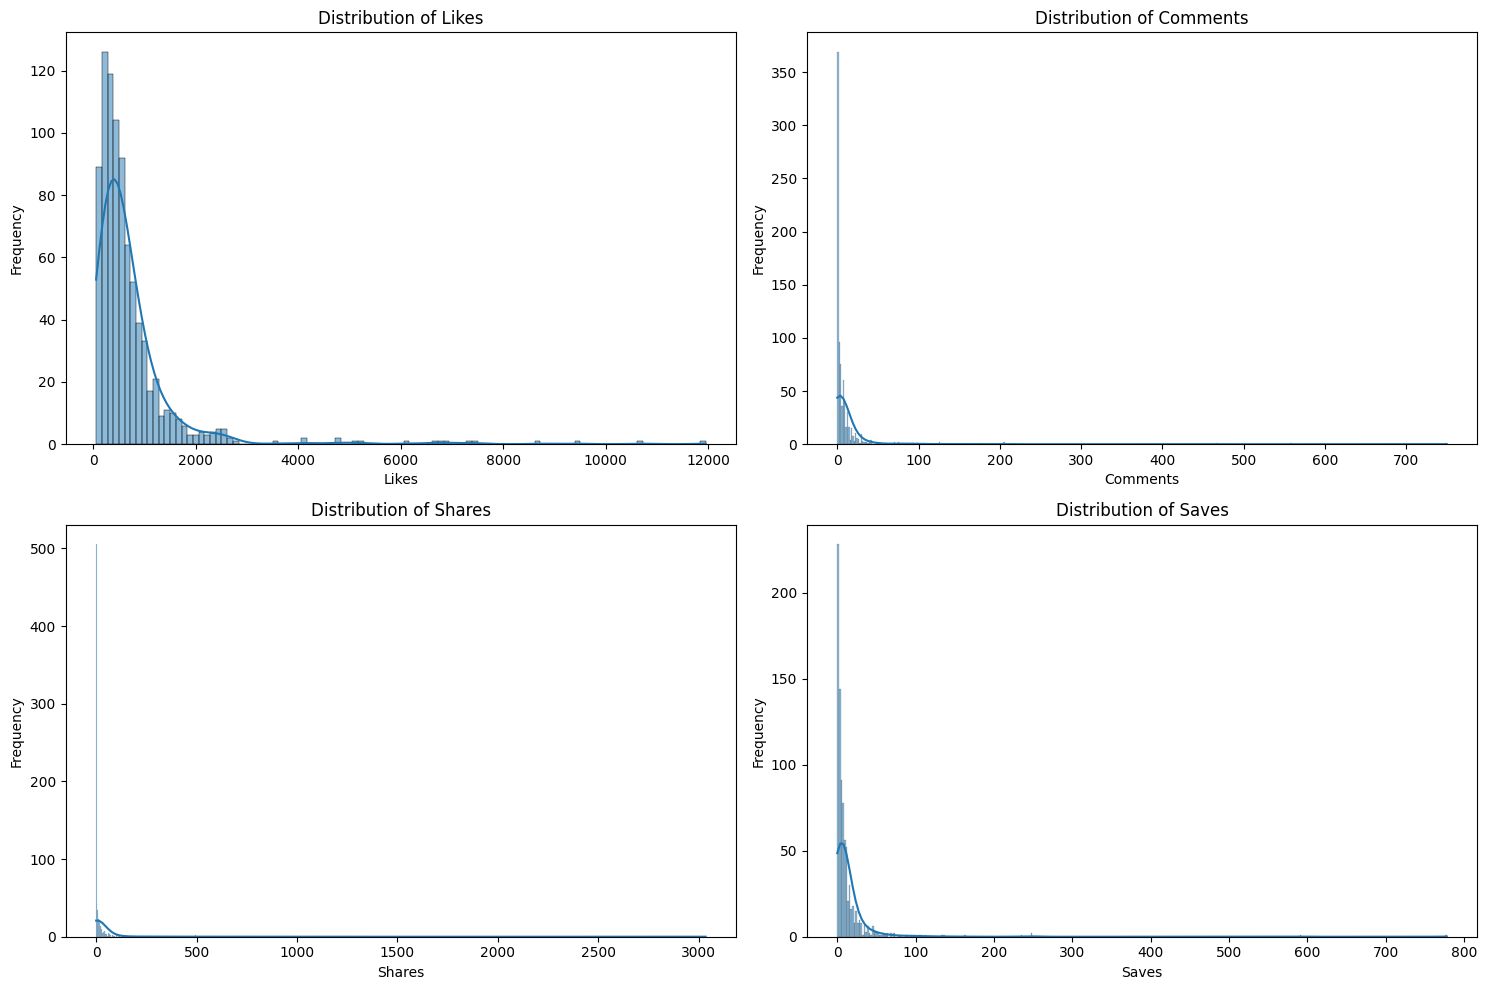

In [310]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate descriptive statistics for key interaction metrics
interaction_metrics = ['Likes', 'Comments', 'Shares', 'Saves', 'Views', 'Reach', 'Follows']
print("Descriptive statistics for interaction metrics:")
print(df_posts[interaction_metrics].describe())

# 2.  Plot histograms for 'Likes', 'Comments', 'Shares', and 'Saves'
plt.figure(figsize=(15, 10)) # 设置图表大小 / Set the figure size

plt.subplot(2, 2, 1) #  First subplot
#Plot histogram for Likes with KDE
sns.histplot(df_posts['Likes'], kde=True)
plt.title('Distribution of Likes')
plt.xlabel('Likes')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2) # Second subplot
#  Plot histogram for Comments with KDE
sns.histplot(df_posts['Comments'], kde=True)
plt.title('Distribution of Comments')
plt.xlabel('Comments')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3) #  Third subplot
#  Plot histogram for Shares with KDE
sns.histplot(df_posts['Shares'], kde=True)
plt.title('Distribution of Shares')
plt.xlabel('Shares')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4) # Fourth subplot
 #  Plot histogram for Saves with KDE
sns.histplot(df_posts['Saves'], kde=True)
plt.title('Distribution of Saves')
plt.xlabel('Saves')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

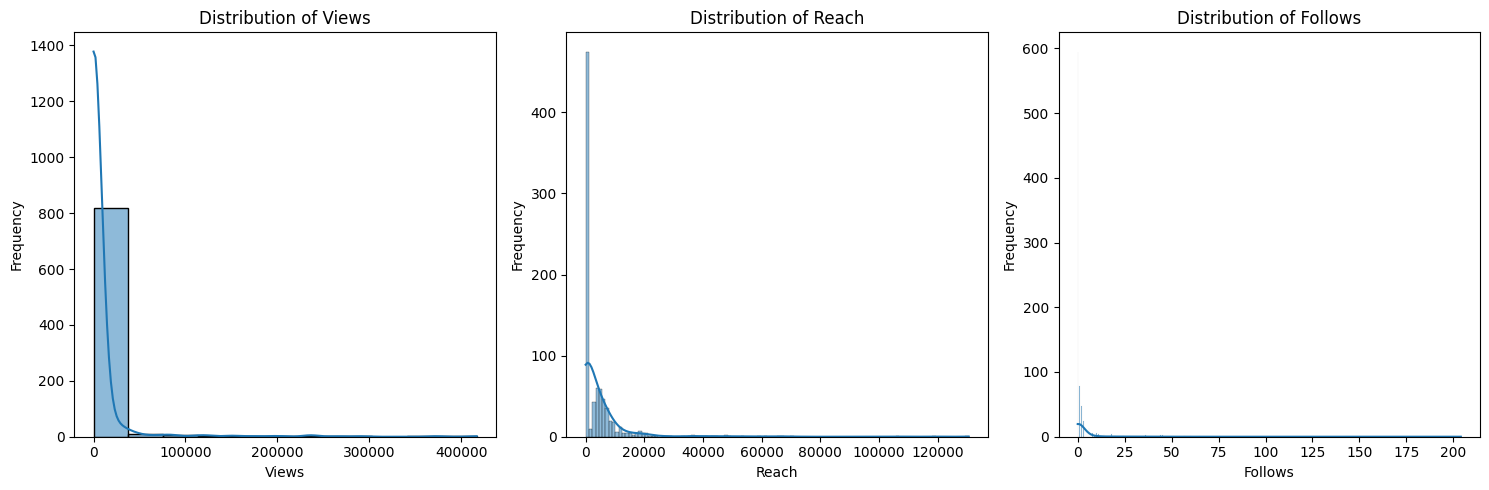

In [311]:
#----BAR CHART----
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1) # First subplot
 # Plot histogram for Views with KDE
sns.histplot(df_posts['Views'], kde=True)
plt.title('Distribution of Views')
plt.xlabel('Views')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2) #  Second subplot
#  Plot histogram for Reach with KDE
sns.histplot(df_posts['Reach'], kde=True)
plt.title('Distribution of Reach')
plt.xlabel('Reach')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3) #  Third subplot
#  Plot histogram for Follows with KDE
sns.histplot(df_posts['Follows'], kde=True)
plt.title('Distribution of Follows')
plt.xlabel('Follows')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

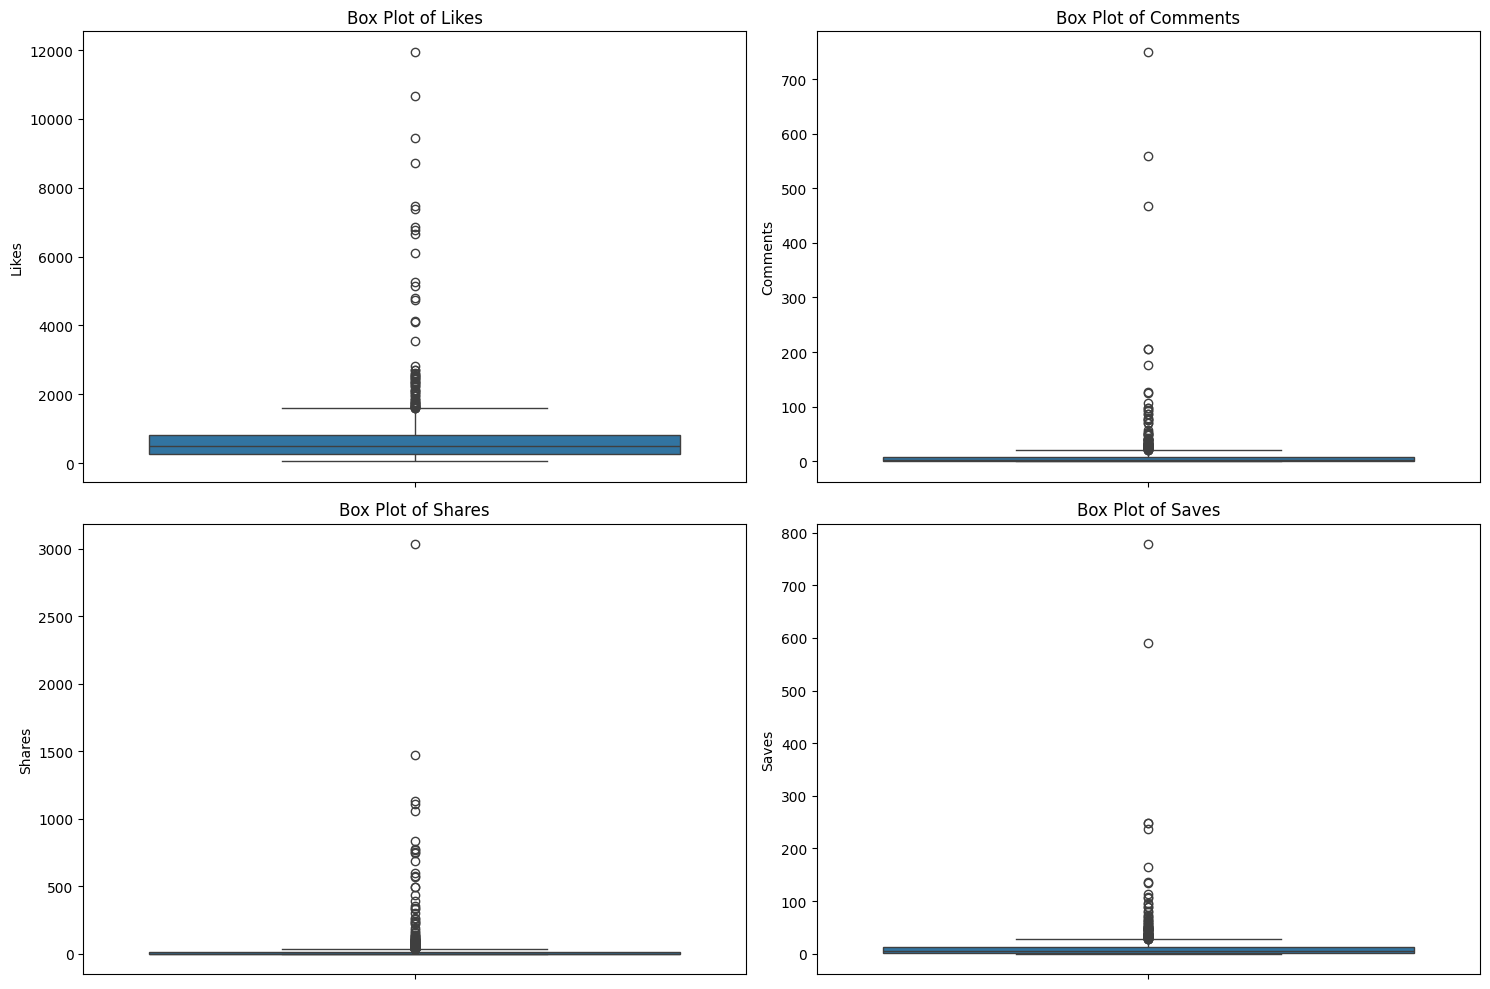

In [312]:
# ----BOX PLOT For Likes, Comments, Shares and Saves------

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1) #  First subplot
#for Likes
sns.boxplot(y=df_posts['Likes'])
plt.title('Box Plot of Likes')
plt.ylabel('Likes')

plt.subplot(2, 2, 2) # Second subplot
# for Comments
sns.boxplot(y=df_posts['Comments'])
plt.title('Box Plot of Comments')
plt.ylabel('Comments')

plt.subplot(2, 2, 3) # Third subplot
# for Shares
sns.boxplot(y=df_posts['Shares'])
plt.title('Box Plot of Shares')
plt.ylabel('Shares')

plt.subplot(2, 2, 4) # Fourth subplot
#for Saves
sns.boxplot(y=df_posts['Saves'])
plt.title('Box Plot of Saves')
plt.ylabel('Saves')

plt.tight_layout()
plt.show()

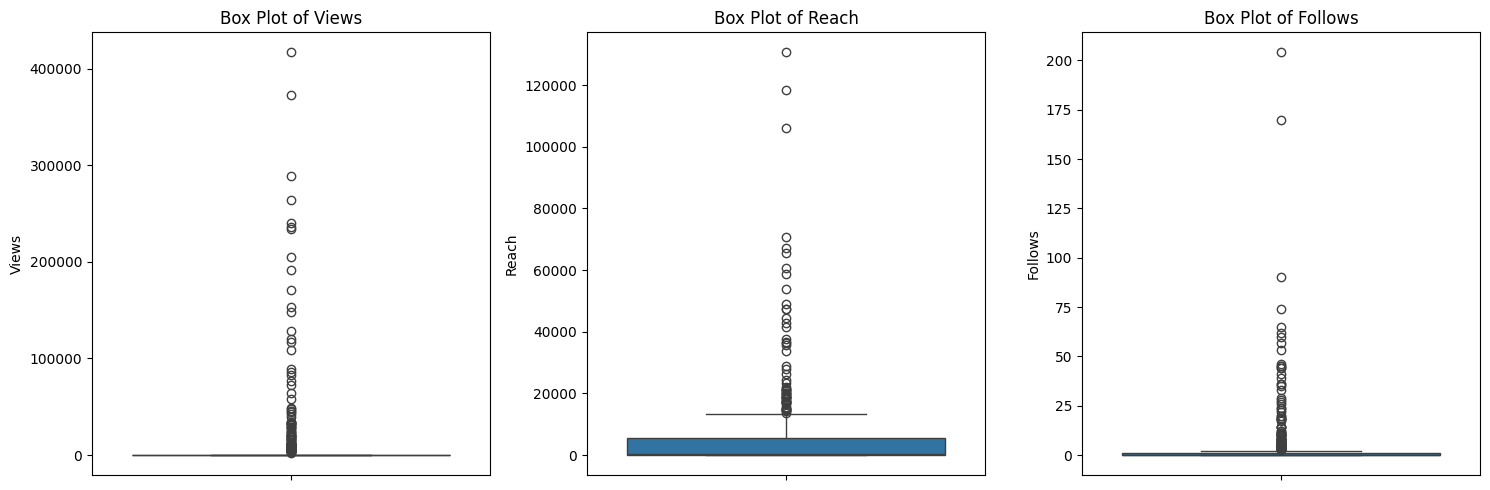

In [313]:
# ----BOX PLOT For Views, Reach, and Follows------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1) # First subplot
sns.boxplot(y=df_posts['Views']) #Views
plt.title('Box Plot of Views')
plt.ylabel('Views')

plt.subplot(1, 3, 2) #  Second subplot
sns.boxplot(y=df_posts['Reach']) # Reach
plt.title('Box Plot of Reach')
plt.ylabel('Reach')

plt.subplot(1, 3, 3) # Third subplot
sns.boxplot(y=df_posts['Follows']) # Follows
plt.title('Box Plot of Follows')
plt.ylabel('Follows')

plt.tight_layout()
plt.show()

### Key Findings:

**1. Descriptive Statistics Information (Descriptive Statistics Summary):**
- **Likes**: The average number of likes is approximately 733, but the standard deviation is relatively large (1036), indicating high data dispersion. The maximum value reaches 11948, which is far above the average, suggesting the existence of highly-liked posts.
- **Comments**: The average number of comments is low (about 10), and the standard deviation is also large (39), indicating that most posts have few comments, but a small number of posts have a very high volume of comments (maximum value 750).
- **Shares**: Both the average number of shares (about 33) and the standard deviation (156) indicate that most posts have a low share volume, but there are a very few posts with a very high share volume (maximum value 3034).
- **Saves**: The average number of saves (about 13) and standard deviation (39) also show a similar pattern, with a small number of posts being saved extensively (maximum value 778).
- **Views**: The average number of views is approximately 6460, but the standard deviation is huge (32329), far exceeding the average. A minimum value of 0 indicates that many posts have no views (possibly non-video content or missing data), while the maximum value is as high as 416994, indicating that the distribution of views is highly skewed and contains a large number of outliers.
- **Reach**: The average reach is approximately 4455, and the standard deviation (10604) is also very large, presenting a high degree of skewness. The maximum value is 130611.
- **Follows**: The average number of new follows is very low (about 2.7), and the standard deviation (12) is also relatively large, with a maximum value of 204, similarly presenting a high degree of skewness.

**2.Histogram Analysis:**
- **Likes, Comments, Shares, Saves, Views, Reach, Follows**: The histograms for all these engagement metrics show a severe right-skewed distribution (right-skewed distribution). This means that the majority of posts have low engagement, while a few "viral" or highly popular posts receive a disproportionately large amount of engagement. The KDE curves further confirm this skewness.

**3. Box Plot Analysis:**
- **Likes, Comments, Shares, Saves, Views, Reach, Follows**: The box plots for all engagement metrics indicate the presence of a large number of outliers (outliers), which are concentrated at the upper end of the distribution. This further confirms the right skewness observed in the histograms and emphasizes the significant impact of a few high-engagement posts on the overall distribution. For example, in the charts for likes, comments, etc., a large number of points can be seen distributed far above the boxes.

**Overall Summary:**
The engagement metrics of the entire dataset exhibit a highly skewed distribution characteristic; the vast majority of posts have low levels of engagement, while a few popular posts contribute to the vast majority of the engagement. This distribution characteristic requires special attention during analysis and modeling, potentially necessitating data transformation (such as log transformation) or the use of models that are insensitive to outliers. The widespread presence of outliers also suggests that there may be different types of posts (e.g., specific content types or promotional campaigns) resulting in vastly different engagement performance.

## NLP Analysis



In [314]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab')
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [315]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

#  text preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return filtered_tokens

#
print("Applying text preprocessing to 'Description' column...")
df_posts.loc[:, 'cleaned_description'] = df_posts['Description'].apply(preprocess_text)
print("First 5 cleaned descriptions:")
print(df_posts[['Description', 'cleaned_description']].head())

print("\nDataFrame Info after adding 'cleaned_description' column:")

Applying text preprocessing to 'Description' column...
First 5 cleaned descriptions:
                                         Description  \
0  Love the energy and Trojan spirit in the stadi...   
1  Tough loss, @uscfb. An incredible run this yea...   
2  The holidays may be over, but I wanted to shar...   
3  Welcome back, Trojans. Wishing you an outstand...   
4    Huge win against #2 Stanford! Congrats @uscwbb!   

                                 cleaned_description  
0  [love, energy, trojan, spirit, stadium, today,...  
1  [tough, loss, uscfb, incredible, run, year, th...  
2  [holiday, may, wanted, share, great, pic, toy,...  
3  [welcome, back, trojan, wishing, outstanding, ...  
4            [huge, win, stanford, congrats, uscwbb]  

DataFrame Info after adding 'cleaned_description' column:


In [316]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return filtered_tokens

print("---Applying text preprocessing to 'Description' column---")
df_posts.loc[:, 'cleaned_description'] = df_posts['Description'].apply(preprocess_text)
print("---Displaying first 5 cleaned descriptions---")
print(df_posts[['Description', 'cleaned_description']].head())

print("\n---DataFrame Info after adding 'cleaned_description' column---")
df_posts.info()

---Applying text preprocessing to 'Description' column---
---Displaying first 5 cleaned descriptions---
                                         Description  \
0  Love the energy and Trojan spirit in the stadi...   
1  Tough loss, @uscfb. An incredible run this yea...   
2  The holidays may be over, but I wanted to shar...   
3  Welcome back, Trojans. Wishing you an outstand...   
4    Huge win against #2 Stanford! Congrats @uscwbb!   

                                 cleaned_description  
0  [love, energy, trojan, spirit, stadium, today,...  
1  [tough, loss, uscfb, incredible, run, year, th...  
2  [holiday, may, wanted, share, great, pic, toy,...  
3  [welcome, back, trojan, wishing, outstanding, ...  
4            [huge, win, stanford, congrats, uscwbb]  

---DataFrame Info after adding 'cleaned_description' column---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  -----

In [317]:

sia = SentimentIntensityAnalyzer()

# Define a sentiment analysis function to get the compound score
def get_sentiment_score(text):
    if not isinstance(text, str):
        return 0.0
    return sia.polarity_scores(text)['compound']

df_posts.loc[:, 'sentiment_score'] = df_posts['Description'].apply(get_sentiment_score)
print("Sentiment analysis complete. Displaying first 5 descriptions with sentiment scores:")
print(df_posts[['Description', 'sentiment_score']].head())

print("\nDataFrame Info after adding 'sentiment_score' column:")
df_posts.info()

Sentiment analysis complete. Displaying first 5 descriptions with sentiment scores:
                                         Description  sentiment_score
0  Love the energy and Trojan spirit in the stadi...           0.6900
1  Tough loss, @uscfb. An incredible run this yea...           0.2500
2  The holidays may be over, but I wanted to shar...           0.9870
3  Welcome back, Trojans. Wishing you an outstand...           0.7644
4    Huge win against #2 Stanford! Congrats @uscwbb!           0.8774

DataFrame Info after adding 'sentiment_score' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Post ID              847 non-null    int64  
 1   Account ID           847 non-null    int64  
 2   Account username     847 non-null    object 
 3   Account name         847 non-null    object 
 4   Description          847 non-nu

In [318]:
from collections import Counter
#  Extract all preprocessed words and count the frenquency
all_words = [word for sublist in df_posts['cleaned_description'] for word in sublist]
word_counts = Counter(all_words)

#  Get the top 20 most common words
top_n = 15
top_words = word_counts.most_common(top_n)

print(f"Top {top_n} most common words:")
for word, count in top_words:
    print(f"{word}: {count}")

Top 15 most common words:
trojan: 243
student: 189
fight: 154
uscedu: 107
fighton: 106
new: 98
usc: 95
day: 91
year: 88
family: 82
community: 74
happy: 71
great: 70
congrats: 70
campus: 69


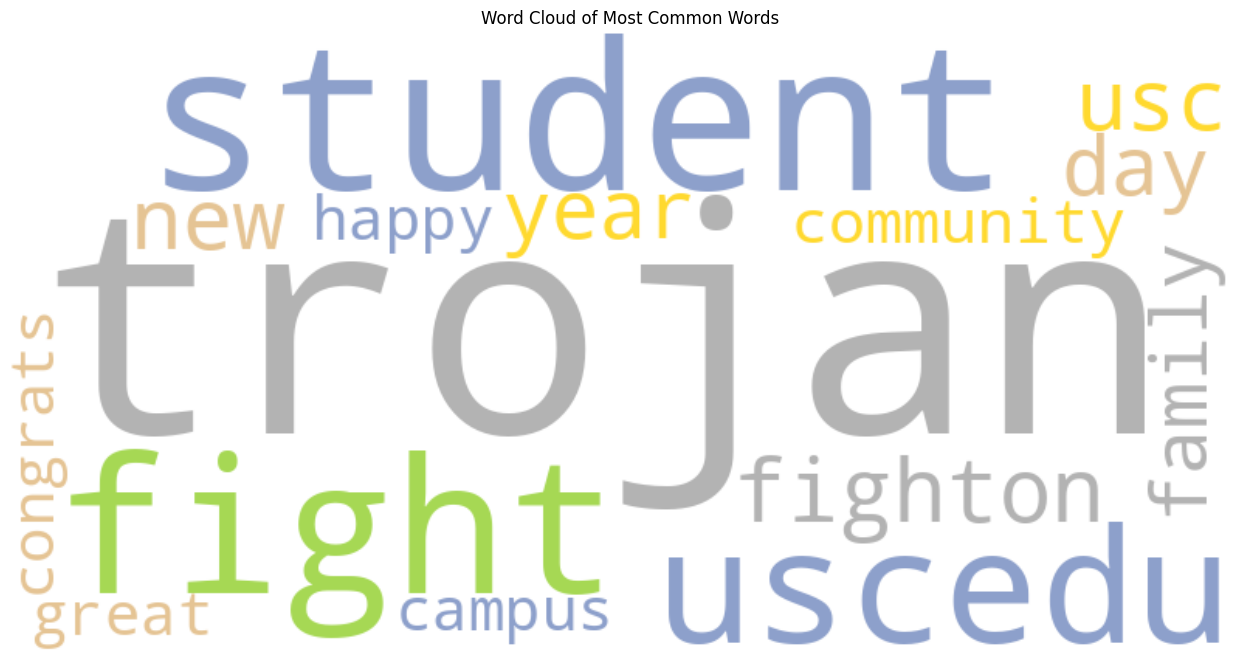

In [319]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud_data = {word: count for word, count in top_words}

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=top_n,
    colormap='Set2'
).generate_from_frequencies(wordcloud_data)


plt.figure(figsize=(16
                    , 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Common Words')
plt.show()

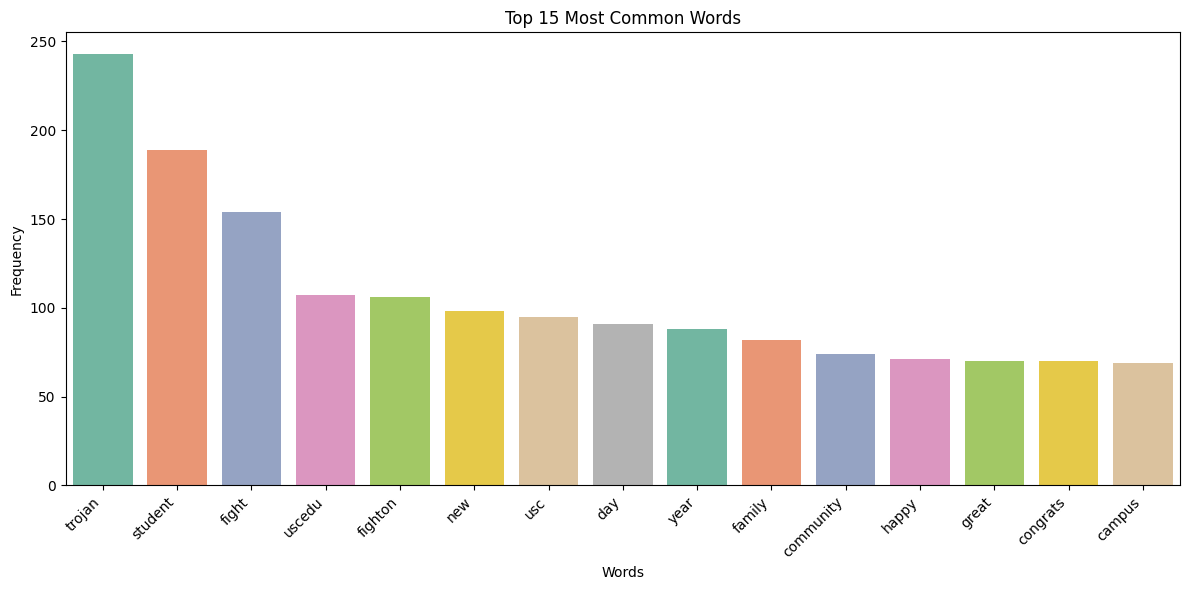

In [320]:

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

#  bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=words, y=counts, palette='Set2', hue=words, legend=False)
plt.title(f'Top {top_n} Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 基于时间的互动分析

### Subtask:
将日期时间相关的列转换为标准datetime格式。分析不同时间尺度（如小时、天、周、月）的帖子互动（点赞、评论）趋势，识别互动高峰期。可视化互动量随时间的变化趋势，例如使用折线图。


In [321]:
# Extract 'hour_of_day'、'day_of_week'and 'month'from  'Publish time'

df_posts['Publish time'] = pd.to_datetime(df_posts['Publish time'])
df_posts.loc[:, 'hour_of_day'] = df_posts['Publish time'].dt.hour
df_posts.loc[:, 'day_of_week'] = df_posts['Publish time'].dt.day_name()
df_posts.loc[:, 'month'] = df_posts['Publish time'].dt.month_name()


# Calculate Shares, Comments, and Saves for  'hour_of_day'
# Store the result in `engagement_by_hour`
print("---Average engagement by hour of day---")
engagement_by_hour = df_posts.groupby('hour_of_day')[['Likes', 'Comments', 'Shares', 'Saves']].mean().reset_index()
print("\nFirst 5 rows of engagement_by_hour:")
print(engagement_by_hour.head())
print("\nDataFrame Info after adding time-based columns:")
df_posts.info()

---Average engagement by hour of day---

First 5 rows of engagement_by_hour:
   hour_of_day         Likes   Comments      Shares       Saves
0            0  10659.000000  97.000000  601.000000    0.000000
1            6   2519.000000  22.000000    0.000000  105.000000
2            7    573.000000   0.000000   19.000000   15.500000
3            8    501.571429   3.714286   12.142857    5.000000
4            9    924.937500  24.937500   51.645833   24.145833

DataFrame Info after adding time-based columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Post ID              847 non-null    int64         
 1   Account ID           847 non-null    int64         
 2   Account username     847 non-null    object        
 3   Account name         847 non-null    object        
 4   Description          847 non-null    o

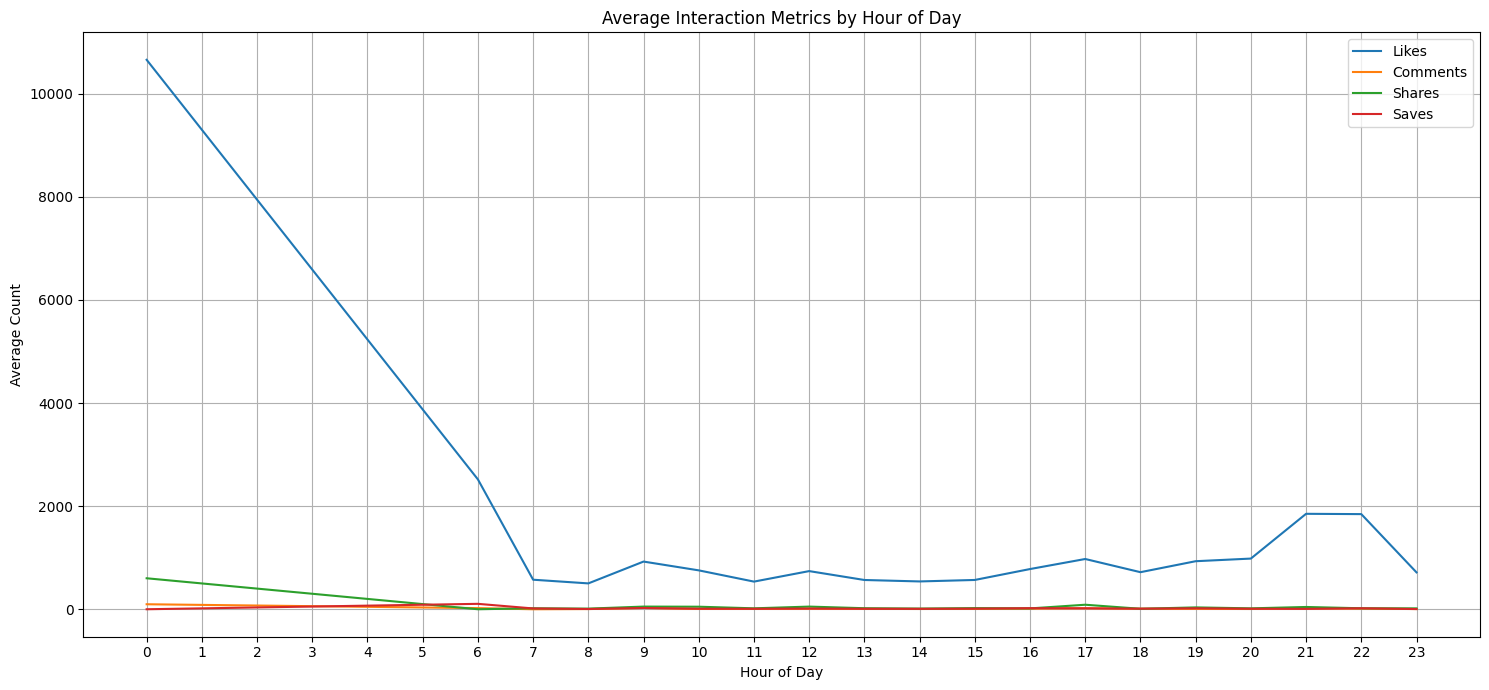

In [322]:
plt.figure(figsize=(15, 7))

#  Likes over hours
sns.lineplot(x='hour_of_day', y='Likes', data=engagement_by_hour, label='Likes')
# Comments over hours
sns.lineplot(x='hour_of_day', y='Comments', data=engagement_by_hour, label='Comments')
# Shares over hours
sns.lineplot(x='hour_of_day', y='Shares', data=engagement_by_hour, label='Shares')
#  Saves over hours
sns.lineplot(x='hour_of_day', y='Saves', data=engagement_by_hour, label='Saves')

plt.title('Average Interaction Metrics by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Count')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [323]:
# Calculate average engagement metrics for each 'day_of_week'
#  Ensure 'day_of_week' is ordered correctly before calculating averages
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_posts.loc[:, 'day_of_week'] = pd.Categorical(df_posts['day_of_week'], categories=day_order, ordered=True)


engagement_by_day = df_posts.groupby('day_of_week')[['Likes', 'Comments', 'Shares', 'Saves']].mean().reset_index()

print("---First 5 rows of engagement_by_day---")
print(engagement_by_day.head())

---First 5 rows of engagement_by_day---
  day_of_week       Likes   Comments     Shares      Saves
0      Friday  742.291667   7.979167  39.006944  11.736111
1      Monday  691.556522   4.686957  26.208696  10.747826
2    Saturday  878.043478   7.021739  21.630435   9.478261
3      Sunday  900.552632  13.157895  37.302632  11.592105
4    Thursday  793.825503  18.838926  32.174497  22.208054


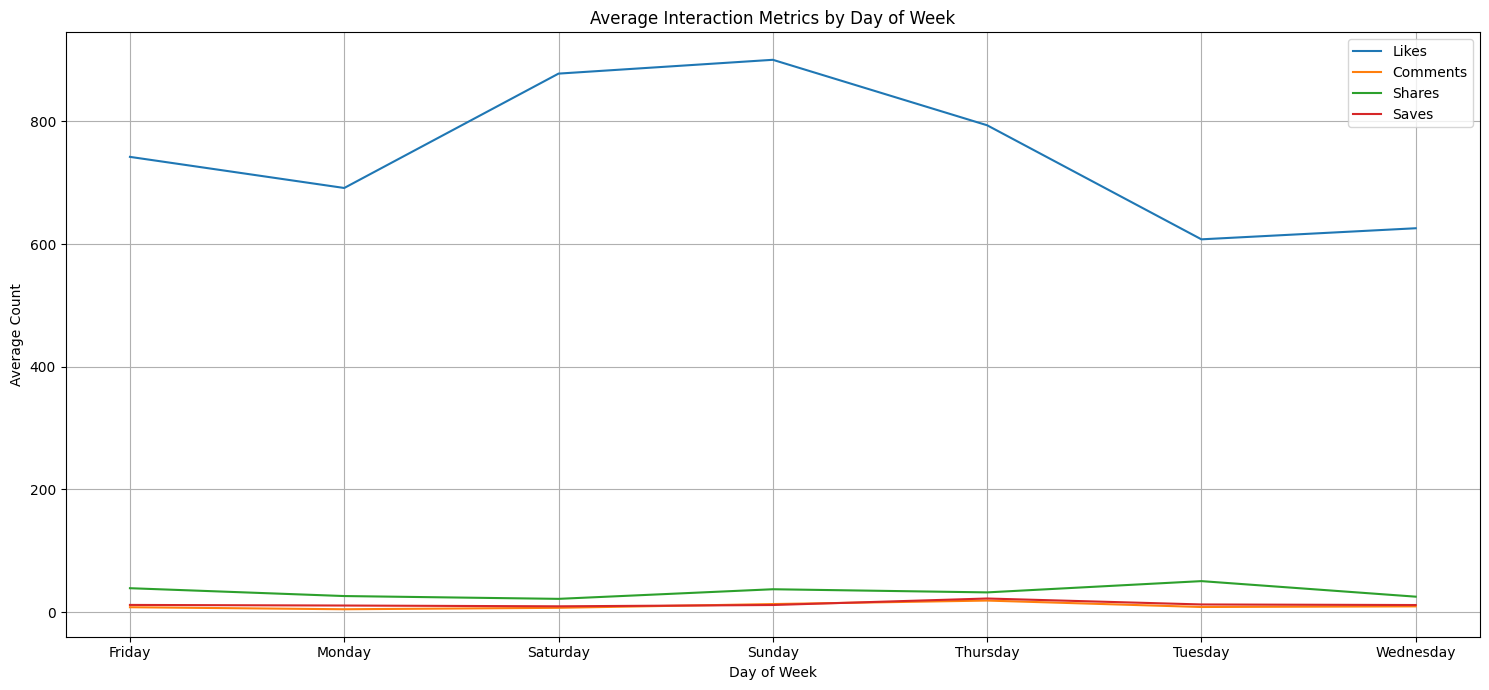

In [324]:
plt.figure(figsize=(15, 7))

#  line chart for Likes over days of week
sns.lineplot(x='day_of_week', y='Likes', data=engagement_by_day, label='Likes')
# line chart for Comments over days of week
sns.lineplot(x='day_of_week', y='Comments', data=engagement_by_day, label='Comments')
# line chart for Shares over days of week
sns.lineplot(x='day_of_week', y='Shares', data=engagement_by_day, label='Shares')
#  line chart for Saves over days of week
sns.lineplot(x='day_of_week', y='Saves', data=engagement_by_day, label='Saves')

plt.title('Average Interaction Metrics by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Count')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [325]:
# Calculate average engagement metrics for each 'month'
#  Ensure 'month' is ordered correctly before calculating averages

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_posts.loc[:, 'month'] = pd.Categorical(df_posts['month'], categories=month_order, ordered=True)

engagement_by_month = df_posts.groupby('month')[['Likes', 'Comments', 'Shares', 'Saves']].mean().reset_index()
print("\n---First 5 rows of engagement_by_month---")
print(engagement_by_month.head())


---First 5 rows of engagement_by_month---
      month       Likes   Comments     Shares      Saves
0     April  584.441860   7.546512  44.569767  18.883721
1    August  751.337838   8.486486  22.851351  11.729730
2  December  701.175439   9.140351  13.719298   9.070175
3  February  395.013514   3.229730  13.675676   5.702703
4   January  955.000000  11.745763  64.813559  10.406780


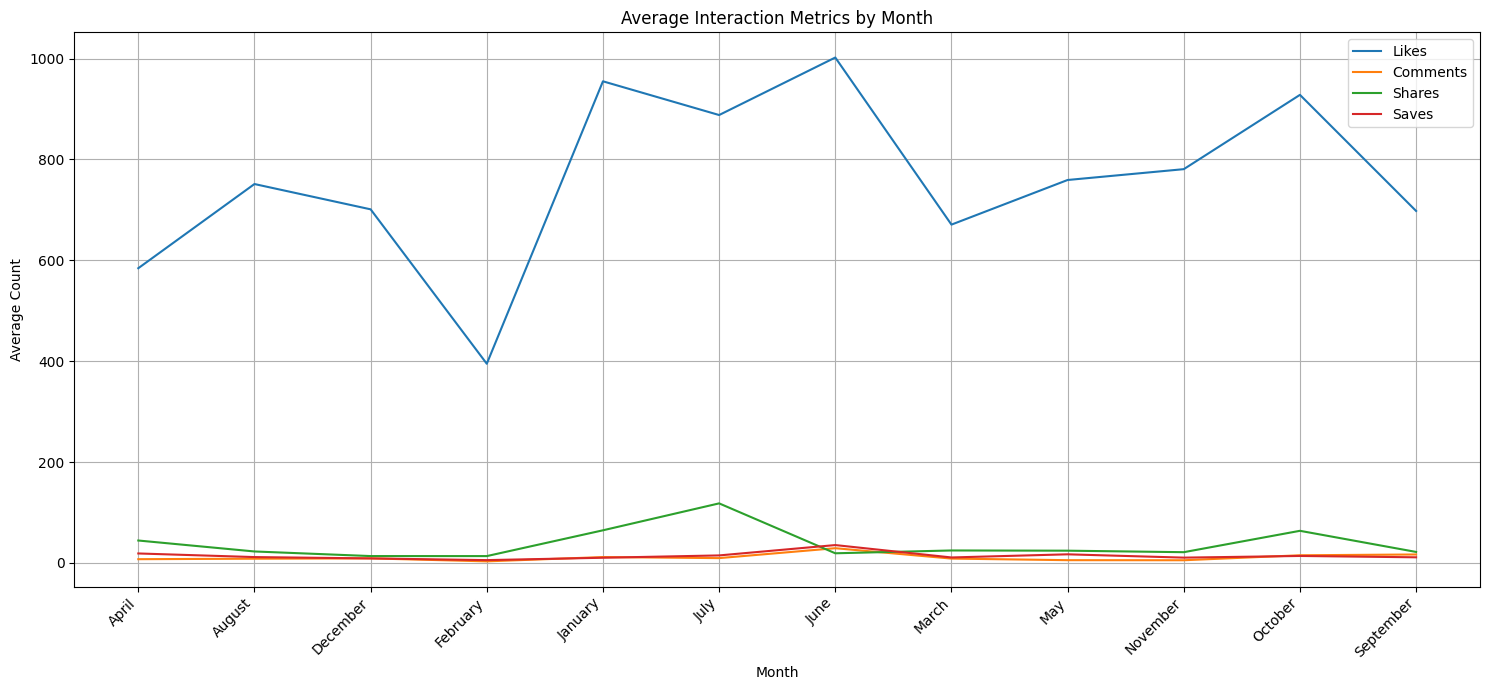

In [326]:
plt.figure(figsize=(15, 7))

#  line chart for Likes over months
sns.lineplot(x='month', y='Likes', data=engagement_by_month, label='Likes')
#  Comments over months
sns.lineplot(x='month', y='Comments', data=engagement_by_month, label='Comments')
# Shares over months
sns.lineplot(x='month', y='Shares', data=engagement_by_month, label='Shares')
#  Saves over months
sns.lineplot(x='month', y='Saves', data=engagement_by_month, label='Saves')

plt.title('Average Interaction Metrics by Month')
plt.xlabel('Month')
plt.ylabel('Average Count')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Engagement Based on Content Type


In [327]:
# Calculate average engagement metrics for each 'content_type'
interaction_metrics_content = ['Likes', 'Comments', 'Shares', 'Saves', 'Views', 'Reach', 'Follows']
print("Calculating average engagement by content type...")
engagement_by_content_type = df_posts.groupby('content_type')[interaction_metrics_content].mean().reset_index()
print("Average engagement by content type calculated.")

# Print the first few rows of engagement_by_content_type DataFrame to check the results
print("\nFirst 5 rows of engagement_by_content_type:")
print(engagement_by_content_type.head())

Calculating average engagement by content type...
Average engagement by content type calculated.

First 5 rows of engagement_by_content_type:
                          content_type        Likes   Comments      Shares  \
0                         Announcement  1205.812500  39.550000  105.887500   
1  Casual Engagement / Social Advocacy   728.626016  11.479675   45.113821   
2                  Events & Activities   655.864553   5.752161   19.204611   
3                           Networking   638.230769   3.782051   34.435897   
4               Recognition/Motivation   720.022831   7.680365   23.200913   

       Saves         Views        Reach   Follows  
0  34.575000  16816.700000  7854.825000  8.687500  
1  19.016260   4538.130081  2167.024390  1.764228  
2   9.348703   6073.409222  4692.051873  2.057637  
3  10.179487   3289.641026  4872.692308  4.051282  
4   9.607306   5500.324201  3974.977169  1.821918  


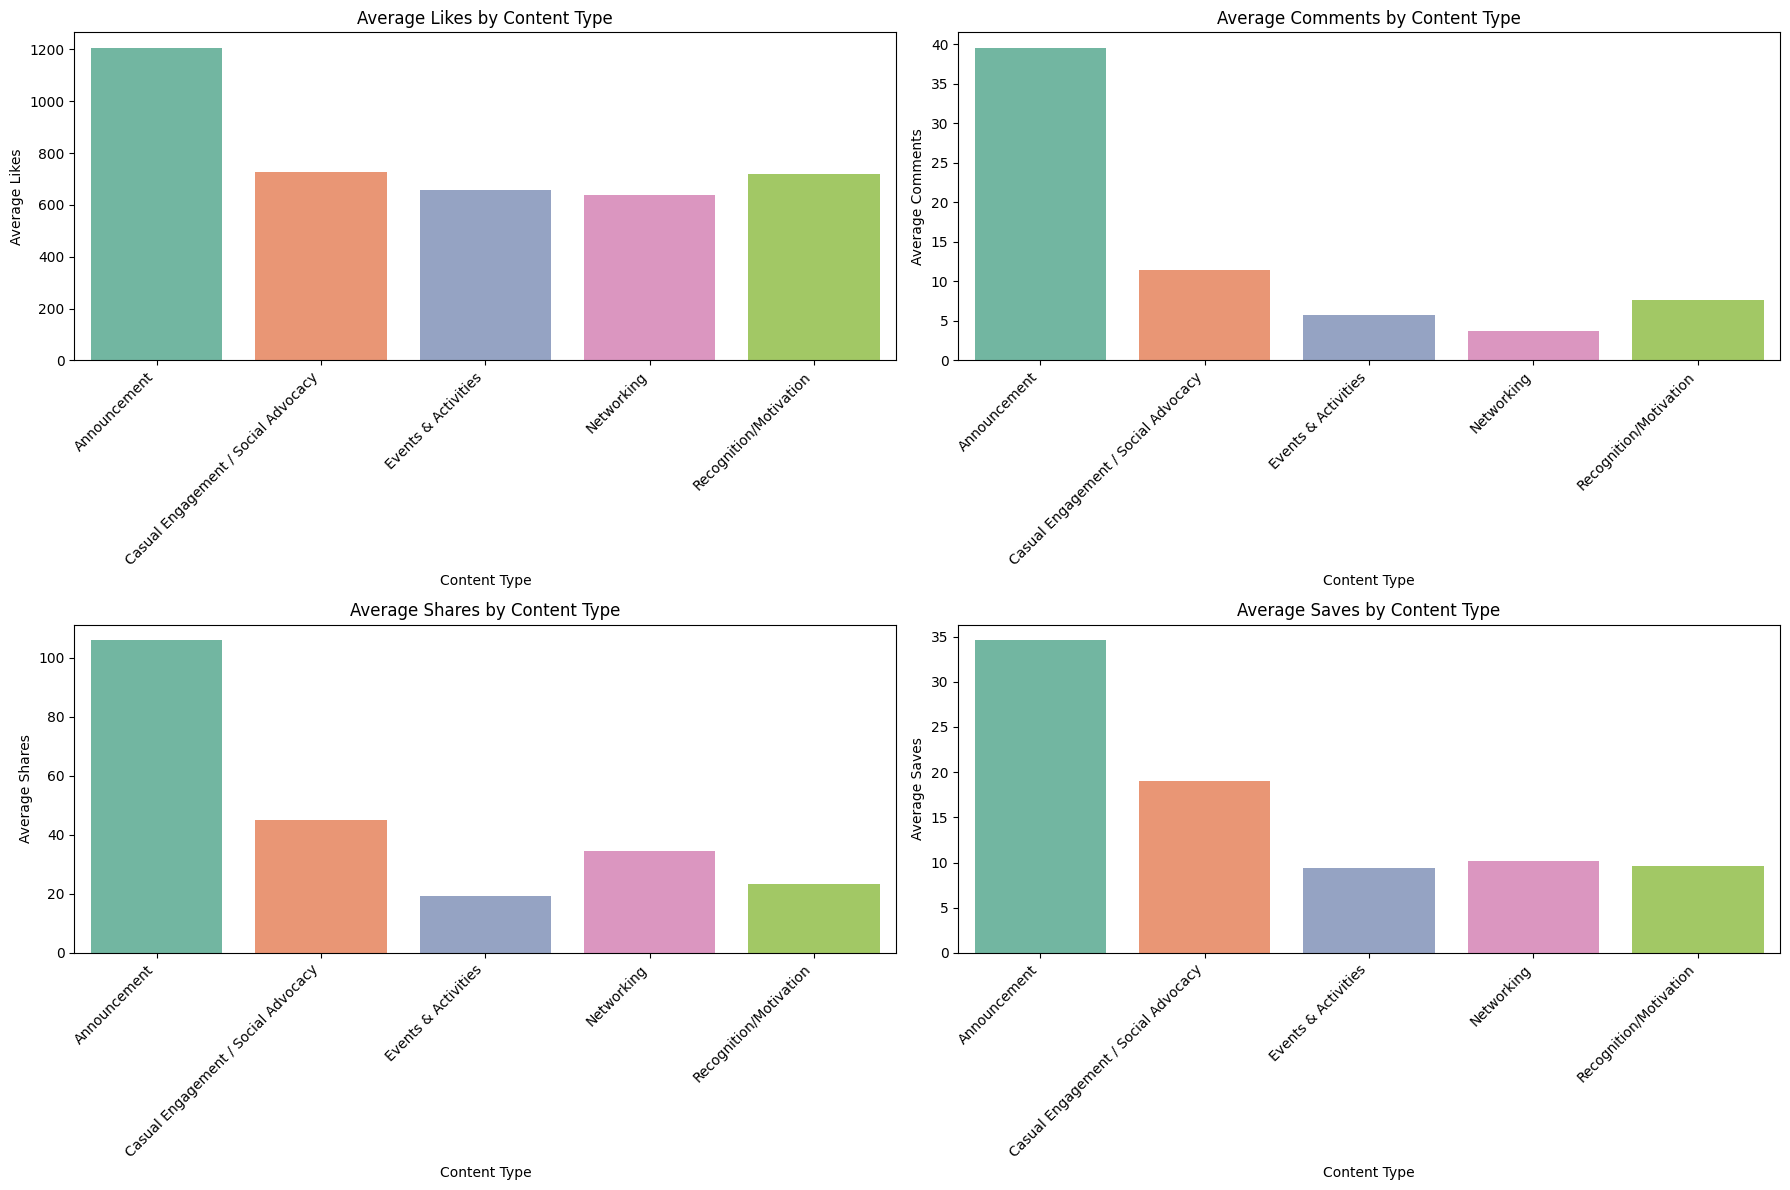

In [328]:
plt.figure(figsize=(18, 12))

# 'content_type'  AVERAGE 'Likes', 'Comments', 'Shares' and 'Saves'
#  Plot average Likes
plt.subplot(2, 2, 1) # First subplot
sns.barplot(x='content_type', y='Likes', data=engagement_by_content_type, hue='content_type', palette='Set2', legend=False)
plt.title('Average Likes by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average Likes')
plt.xticks(rotation=45, ha='right')

#Plot average Comments
plt.subplot(2, 2, 2) #  Second subplot
sns.barplot(x='content_type', y='Comments', data=engagement_by_content_type, hue='content_type', palette='Set2', legend=False)
plt.title('Average Comments by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average Comments')
plt.xticks(rotation=45, ha='right')

# Plot average Shares
plt.subplot(2, 2, 3) # Third subplot
sns.barplot(x='content_type', y='Shares', data=engagement_by_content_type, hue='content_type', palette='Set2', legend=False)
plt.title('Average Shares by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average Shares')
plt.xticks(rotation=45, ha='right')

#  Plot average Saves
plt.subplot(2, 2, 4) #  Fourth subplot
sns.barplot(x='content_type', y='Saves', data=engagement_by_content_type, hue='content_type', palette='Set2', legend=False)
plt.title('Average Saves by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average Saves')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

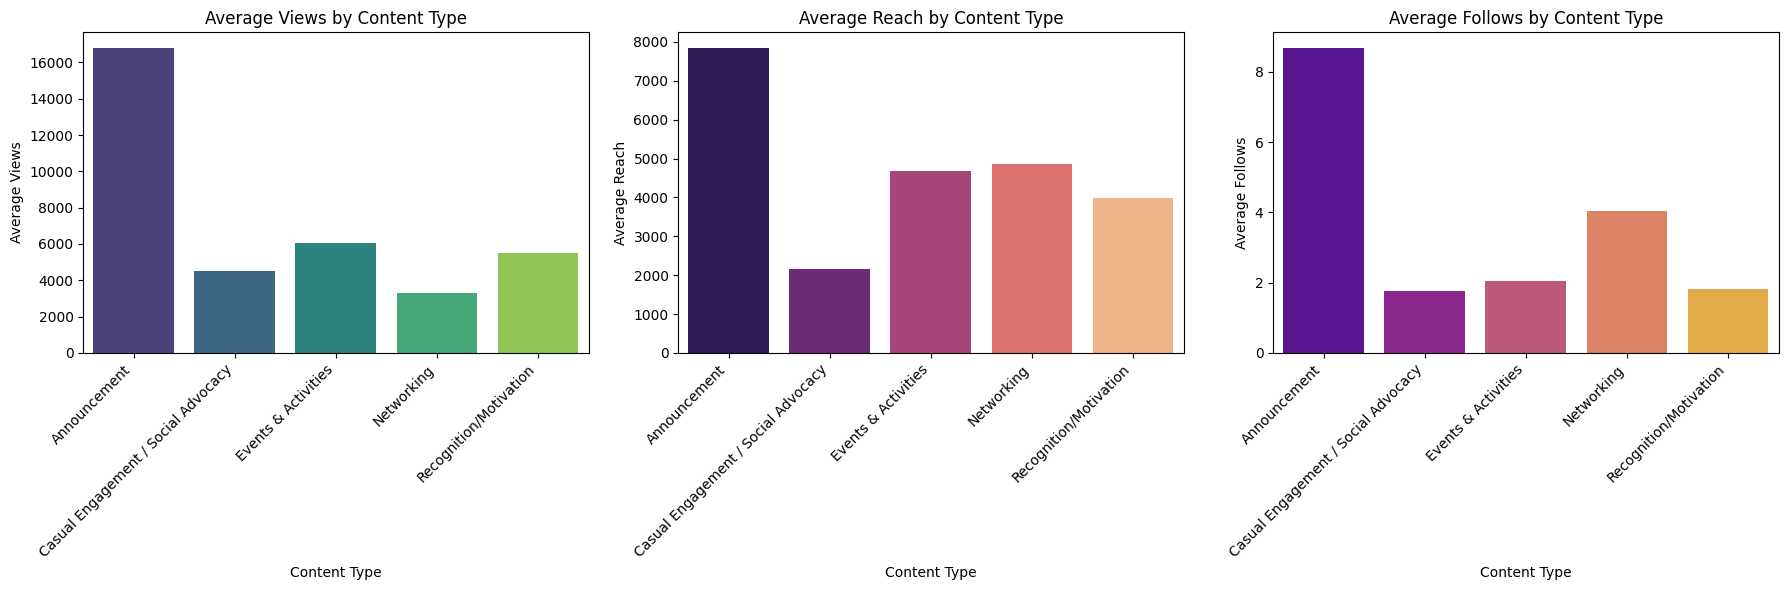

In [329]:
plt.figure(figsize=(18, 6))

# Average 'Views', 'Reach' , and'Follows' for 'content_type'
# Plot average Views
plt.subplot(1, 3, 1) #  First subplot
sns.barplot(x='content_type', y='Views', data=engagement_by_content_type, palette='viridis', hue='content_type', legend=False)
plt.title('Average Views by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average Views')
plt.xticks(rotation=45, ha='right')

#  average Reach
plt.subplot(1, 3, 2) # Second subplot
sns.barplot(x='content_type', y='Reach', data=engagement_by_content_type, palette='magma', hue='content_type', legend=False)
plt.title('Average Reach by Content Type') # Set title
plt.xlabel('Content Type')
plt.ylabel('Average Reach')
plt.xticks(rotation=45, ha='right')

# Plot average Follows
plt.subplot(1, 3, 3) # Third subplot
sns.barplot(x='content_type', y='Follows', data=engagement_by_content_type, palette='plasma', hue='content_type', legend=False)
plt.title('Average Follows by Content Type') # Set title
plt.xlabel('Content Type')
plt.ylabel('Average Follows')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Data Loading and Cleaning**: The dataset containing 847 Instagram posts and 19 columns was successfully loaded. Data cleaning involved removing an entirely empty column ('Data comment'), filling missing values in text fields ('Account name', 'Description') with 'Unknown', numerical interaction fields ('Views', 'Reach', 'Follows') with 0, and converting 'Publish time' to datetime format. No duplicate rows were found.
*   **Interaction Metrics Distribution**: All key interaction metrics, including Likes, Comments, Shares, Saves, Views, Reach, and Follows, exhibit a severely right-skewed distribution. This indicates that most posts receive low engagement, while a small number of "viral" or highly popular posts garner a disproportionately large amount of interaction. For example, 'Likes' have an average of ~733 but a maximum of ~11,948, and 'Views' average ~6,460 but peak at ~416,994.
*   **Content Text Analysis**: Text preprocessing (lowercasing, punctuation removal, tokenization, stopword removal, and lemmatization) was applied to post descriptions. Sentiment analysis was performed, and the most common words identified were related to the "trojan" theme, "student" life, "fight" (likely referring to sports), and "usc" (University of Southern California), suggesting a focus on university-related content.
*   **Time-Based Engagement Trends**:
    *   **Hourly**: While specific peak hours are not explicitly stated, the analysis reveals varying average engagement throughout the day across Likes, Comments, Shares, and Saves, with average likes at hour 0 being 10659.0 and comments at 97.0.
    *   **Daily**: Engagement metrics fluctuate throughout the week, with Friday showing a relatively high average of 742.29 likes, while Monday averaged 691.56 likes.
    *   **Monthly**: Average engagement also varies by month; for instance, April posts averaged 584.44 likes, whereas January posts averaged 955.00 likes.
*   **Content Type Performance**: Posts categorized as 'Announcement' show significantly higher average engagement, with ~1,205.81 Likes and ~16,816.7 Views, compared to other content types. This suggests that informational or official updates tend to attract more attention.

### Insights or Next Steps

*   **Content Strategy Optimization**: Given that 'Announcement' content types drive significantly higher engagement, the organization should consider producing more high-value, official, or news-driven content. Further analysis could explore specific elements within these "announcement" posts that contribute to their success.
*   **Targeted Posting Schedule**: Leverage the identified time-based trends (hourly, daily, monthly) to optimize posting times. Schedule posts during peak engagement periods for each day and month to maximize reach and interaction, especially for different content types.
